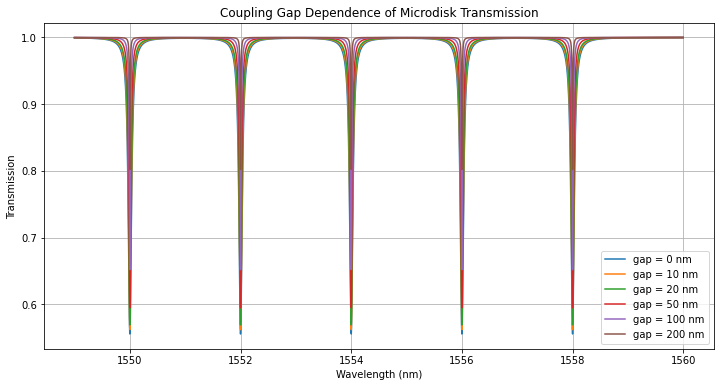

In [4]:
# ============================================================
#   PHOTONIC MICRODISK – COUPLING GAP / MULTI-MODE SPECTRA
#   Complete Jupyter Notebook Script
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1) BASIC PHYSICAL FUNCTIONS
# ============================================================

def lorentzian(wavelength, lambda_0, Q_loaded):
    """Normalized Lorentzian resonance."""
    gamma = lambda_0 / Q_loaded
    return 1 / (1 + 4 * ((wavelength - lambda_0) / gamma)**2)


def coupling_Q_vs_gap(g, Qc0, delta_lambda_max, L_p):
    """
    Exponential gap-dependent coupling Q.
    g = gap distance
    Qc0 = base coupling Q at g=0
    delta_lambda_max = coupling strength scaling
    L_p = penetration depth
    """
    return Qc0 * np.exp(g / L_p) + delta_lambda_max


def transmission_spectrum(
    wavelength, lambda_0, Q_int, Q_c1, Q_c2
):
    """
    Through-port transmission model for a single resonance
    with internal loss + two coupling sections.
    """
    # Load total Q
    Q_loaded = 1 / (1/Q_int + 1/Q_c1 + 1/Q_c2)

    # Lorentzian profile
    L = lorentzian(wavelength, lambda_0, Q_loaded)

    # Classical through-port expression:
    t = 1 - (Q_loaded / Q_c1) * L

    return t


# ============================================================
# 2) MULTI-MODE RESONANCE GENERATOR
# ============================================================

def generate_spectrum(
    wavelength,
    lambda_0, FSR,
    n_modes,
    Q_int, Qc1_base, Qc2_base,
    gap, delta_lambda_max, L_p
):
    """
    Generates a spectrum containing 'n_modes' resonances,
    spaced by the free spectral range (FSR).
    The resonance wavelength shifts: λ_m = λ0 + m*FSR.
    """
    T_total = np.ones_like(wavelength)

    # Gap modifies external coupling Q
    Q_c1 = coupling_Q_vs_gap(gap, Qc1_base, delta_lambda_max, L_p)
    Q_c2 = coupling_Q_vs_gap(gap, Qc2_base, delta_lambda_max, L_p)

    for m in range(n_modes):
        lambda_m = lambda_0 + m * FSR
        T_res = transmission_spectrum(
            wavelength, lambda_m, Q_int, Q_c1, Q_c2
        )
        # Multiply Lorentzian dips
        T_total *= T_res

    return T_total


# ============================================================
# 3) PLOTTING MULTI-GAP SPECTRA
# ============================================================

def plot_spectra(
    wavelength, distances, lambda_0, Q_int, Qc1_base, Qc2_base,
    L_c, delta_lambda_max, L_p,
    FSR, n_modes=3,
    save_fig=False, filename="spectra.png"
):
    """
    Plots multi-mode transmission spectra for different gap distances.
    """

    plt.figure(figsize=(12, 6))

    for g in distances:
        T = generate_spectrum(
            wavelength,
            lambda_0, FSR, n_modes,
            Q_int, Qc1_base, Qc2_base,
            gap=g,
            delta_lambda_max=delta_lambda_max,
            L_p=L_p
        )

        plt.plot(
            wavelength * 1e9,
            T,
            label=f"gap = {g*1e9:.0f} nm"
        )

    plt.title("Coupling Gap Dependence of Microdisk Transmission")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Transmission")
    plt.legend()
    plt.grid(True)

    if save_fig:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()


# ============================================================
# 4) PARAMETERS
# ============================================================

# Wavelength sweep (shows ~5 resonances)
wavelength = np.linspace(1.549e-6, 1.56e-6, 20000)

# Reference resonance
lambda_0 = 1.55e-6

# Free spectral range in wavelength
FSR = 2e-9  # 2 nm

# Quality factors
Q_int = 2e5
Qc1_base = 5e4
Qc2_base = 5e4

# Coupling physics
delta_lambda_max = 50  # strength offset term
L_p = 80e-9             # evanescent penetration depth

# Gap distances to simulate
distances = [0, 10e-9, 20e-9, 50e-9, 100e-9, 200e-9]

L_c = 100e-9  # coupling length (not used directly now but kept for consistency)

# Number of resonances
n_modes = 5


# ============================================================
# 5) RUN SIMULATION AND PLOT
# ============================================================

plot_spectra(
    wavelength,
    distances,
    lambda_0, Q_int, Qc1_base, Qc2_base,
    L_c,
    delta_lambda_max, L_p,
    FSR,
    n_modes=n_modes,
    save_fig=False
)
